# 02 — Input bit-depth sweep (PyTorch)

Sweeps input quantization in [0,2,4,8] with fixed network precision.

In [1]:
from pathlib import Path
import sys, os

# ---- Path setup (adjust if your repo layout differs) ----
PROJECT_ROOT = Path("..").resolve()
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

In [2]:
import pandas as pd

from config import ExperimentConfig, with_overrides
from runner import run_experiment
from utils import load_runs, flatten_runs
from plots import (
    plot_metric_vs_input_bits,
    plot_delta_from_baseline,
    plot_tradeoff_with_pareto,
)

pd.set_option("display.max_columns", 200)


In [3]:

base = ExperimentConfig(
    backend="pytorch",
    device="cuda",
    batch_size=1,       
    seed=42,
    num_eval_batches=500,
)

in_bits_list = [4, 2, 1] 


In [4]:
cfgs32 = [with_overrides(base, input_quant_bits=b, model_precision="fp32") for b in in_bits_list]

records = []
for cfg in cfgs32:
    payload, _ = run_experiment(cfg, split="val", save_results_flag=True)
    records.append(payload)

for r in records:
    print(r["run_id"], r["status"], r["results"].get("top1_acc"))

Evaluating on 500 batches (first 30 are warmup)...
  --- Warmup complete (30 batches) — starting metric collection ---
  Batch [40/500] Top-1: 70.00% | Top-5: 100.00% | Infer: 3.42 ms/batch
  Batch [50/500] Top-1: 85.00% | Top-5: 100.00% | Infer: 3.08 ms/batch
  Batch [60/500] Top-1: 86.67% | Top-5: 96.67% | Infer: 3.17 ms/batch
  Batch [70/500] Top-1: 87.50% | Top-5: 97.50% | Infer: 3.16 ms/batch
  Batch [80/500] Top-1: 86.00% | Top-5: 96.00% | Infer: 5.45 ms/batch
  Batch [90/500] Top-1: 85.00% | Top-5: 96.67% | Infer: 6.07 ms/batch
  Batch [100/500] Top-1: 85.71% | Top-5: 97.14% | Infer: 6.64 ms/batch
  Batch [110/500] Top-1: 83.75% | Top-5: 96.25% | Infer: 6.99 ms/batch
  Batch [120/500] Top-1: 82.22% | Top-5: 95.56% | Infer: 7.14 ms/batch
  Batch [130/500] Top-1: 83.00% | Top-5: 95.00% | Infer: 7.31 ms/batch
  Batch [140/500] Top-1: 81.82% | Top-5: 95.45% | Infer: 7.54 ms/batch
  Batch [150/500] Top-1: 80.00% | Top-5: 95.00% | Infer: 7.82 ms/batch
  Batch [160/500] Top-1: 78.46% |

In [5]:
runs = load_runs("../runs", status="ok")
rows = flatten_runs(runs)
df = pd.DataFrame(rows)

# Filter only what this notebook is responsible for
df_sweep = df[
    (df["cfg.backend"] == "pytorch")
    & (df["cfg.device"] == "cuda")
    & (df["cfg.model_precision"].isin(["fp32"])) 
    & (df["cfg.input_quant_bits"].isin([8, 4, 2, 1]))
].copy()

df_sweep[[
    "run_id",
    "res.top1_acc",
    "res.top5_acc",
    "res.infer_ms_avg",
    "res.throughput_infer_sps",
    "res.total_samples",
]].sort_values(["run_id"])

,run_id,res.top1_acc,res.top5_acc,res.infer_ms_avg,res.throughput_infer_sps,res.total_samples
4,resnet18_pytorch_fp32_in1b_cuda_bs1,1.276596,7.659574,3.982232,251.115461,470
5,resnet18_pytorch_fp32_in2b_cuda_bs1,32.127660,56.170213,4.531244,220.689969,470
6,resnet18_pytorch_fp32_in4b_cuda_bs1,76.170213,93.829787,4.730303,211.402942,470
7,resnet18_pytorch_fp32_in8b_cuda_bs1,78.297872,94.255319,2.957925,338.074874,470


In [6]:
cfgs16 = [with_overrides(base, input_quant_bits=b, model_precision="fp16") for b in in_bits_list]

records = []
for cfg in cfgs16:
    payload, _ = run_experiment(cfg, split="val", save_results_flag=True)
    records.append(payload)

for r in records:
    print(r["run_id"], r["status"], r["results"].get("top1_acc"))

Evaluating on 500 batches (first 30 are warmup)...
  --- Warmup complete (30 batches) — starting metric collection ---
  Batch [40/500] Top-1: 70.00% | Top-5: 100.00% | Infer: 3.69 ms/batch
  Batch [50/500] Top-1: 85.00% | Top-5: 100.00% | Infer: 4.00 ms/batch
  Batch [60/500] Top-1: 86.67% | Top-5: 96.67% | Infer: 3.67 ms/batch
  Batch [70/500] Top-1: 87.50% | Top-5: 97.50% | Infer: 3.57 ms/batch
  Batch [80/500] Top-1: 86.00% | Top-5: 96.00% | Infer: 3.57 ms/batch
  Batch [90/500] Top-1: 85.00% | Top-5: 96.67% | Infer: 3.49 ms/batch
  Batch [100/500] Top-1: 85.71% | Top-5: 97.14% | Infer: 3.39 ms/batch
  Batch [110/500] Top-1: 83.75% | Top-5: 96.25% | Infer: 3.37 ms/batch
  Batch [120/500] Top-1: 82.22% | Top-5: 95.56% | Infer: 3.32 ms/batch
  Batch [130/500] Top-1: 83.00% | Top-5: 95.00% | Infer: 3.38 ms/batch
  Batch [140/500] Top-1: 81.82% | Top-5: 95.45% | Infer: 3.37 ms/batch
  Batch [150/500] Top-1: 80.00% | Top-5: 95.00% | Infer: 3.33 ms/batch
  Batch [160/500] Top-1: 78.46% |

In [7]:
runs = load_runs("../runs", status="ok")
rows = flatten_runs(runs)
df = pd.DataFrame(rows)

# Filter only what this notebook is responsible for
df_sweep = df[
    (df["cfg.backend"] == "pytorch")
    & (df["cfg.device"] == "cuda")
    & (df["cfg.model_precision"].isin(["fp16"])) 
    & (df["cfg.input_quant_bits"].isin([8, 4, 2, 1]))
].copy()

df_sweep[[
    "run_id",
    "res.top1_acc",
    "res.top5_acc",
    "res.infer_ms_avg",
    "res.throughput_infer_sps",
    "res.total_samples",
]].sort_values(["run_id"])

,run_id,res.top1_acc,res.top5_acc,res.infer_ms_avg,res.throughput_infer_sps,res.total_samples
0,resnet18_pytorch_fp16_in1b_cuda_bs1,1.276596,7.659574,3.798208,263.282085,470
1,resnet18_pytorch_fp16_in2b_cuda_bs1,32.127660,56.170213,3.815751,262.071577,470
2,resnet18_pytorch_fp16_in4b_cuda_bs1,75.957447,93.829787,3.867332,258.576194,470
3,resnet18_pytorch_fp16_in8b_cuda_bs1,78.297872,94.255319,2.791566,358.221875,470


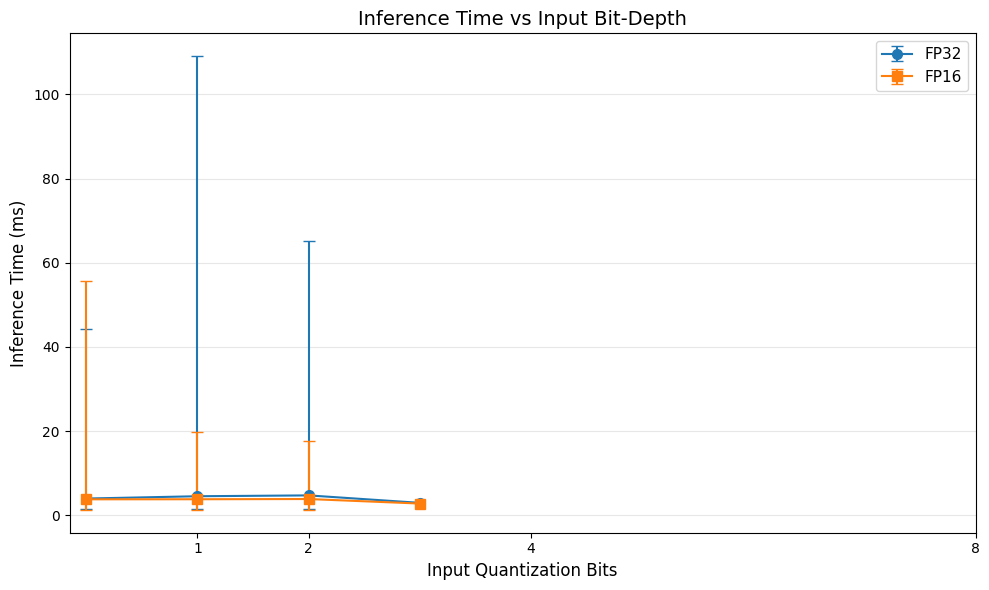

In [8]:
import matplotlib.pyplot as plt

runs = load_runs("../runs", status="ok")
rows = flatten_runs(runs)
df = pd.DataFrame(rows)

# Filter base conditions
base_filter = (df["cfg.backend"] == "pytorch") & (df["cfg.input_quant_bits"].isin([8, 4, 2, 1]))

plt.figure(figsize=(10, 6))

bit_values = sorted(df[base_filter]["cfg.input_quant_bits"].unique())

for precision, marker in [("fp32", "o"), ("fp16", "s")]:
    df_filtered = df[base_filter & (df["cfg.model_precision"] == precision)].sort_values("cfg.input_quant_bits")
    avgs = df_filtered["res.infer_ms_avg"].values
    mins = df_filtered["res.infer_ms_min"].values
    maxs = df_filtered["res.infer_ms_max"].values
    x_vals = [list(bit_values).index(b) for b in df_filtered["cfg.input_quant_bits"].values]

    plt.errorbar(x_vals, avgs, yerr=[avgs - mins, maxs - avgs], marker=marker,
                 capsize=4, linewidth=1.5, markersize=7, label=precision.upper())

plt.xlabel("Input Quantization Bits", fontsize=12)
plt.ylabel("Inference Time (ms)", fontsize=12)
plt.title("Inference Time vs Input Bit-Depth", fontsize=14)
plt.xticks(bit_values)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("inference_time_vs_bits.pdf", backend='pdf')
plt.show()

In [10]:
#accuracy is same for both fp16 and fp32